# EE2213 Project: Multi-Class Classification

#### <span style="color:red">No additional library imports are permitted.</span>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder

## PART 0: Data Loading and Preparation

In [2]:
def load_openml_dataset():

    dataset = fetch_openml(name='vehicle', version=1, as_frame=True, parser='auto')
    X = dataset.data.values
    
    target_values = dataset.target.values
    unique_targets = np.unique(target_values)
    
    # Create mapping from string labels to integers
    label_to_int = {label: i for i, label in enumerate(unique_targets)}
    y = np.array([label_to_int[label] for label in target_values])
    
    feature_names = dataset.feature_names
    
    return X, y, feature_names

X, y, feature_names = load_openml_dataset()
print(f"Feature shape: {X.shape}, target output shape:{y.shape}")
print(f"feature names: {feature_names}")


Feature shape: (846, 18), target output shape:(846,)
feature names: ['COMPACTNESS', 'CIRCULARITY', 'DISTANCE_CIRCULARITY', 'RADIUS_RATIO', 'PR.AXIS_ASPECT_RATIO', 'MAX.LENGTH_ASPECT_RATIO', 'SCATTER_RATIO', 'ELONGATEDNESS', 'PR.AXIS_RECTANGULARITY', 'MAX.LENGTH_RECTANGULARITY', 'SCALED_VARIANCE_MAJOR', 'SCALED_VARIANCE_MINOR', 'SCALED_RADIUS_OF_GYRATION', 'SKEWNESS_ABOUT_MAJOR', 'SKEWNESS_ABOUT_MINOR', 'KURTOSIS_ABOUT_MAJOR', 'KURTOSIS_ABOUT_MINOR', 'HOLLOWS_RATIO']


## PART 1: Dataset Partition and One-hot Encoding

In [3]:
def dataset_partition_encoding(X, y):
    """
    Input type
    :X type: numpy.ndarray of size (number_of_samples, number_of_features)
    :y type: numpy.ndarray of size (number_of_samples,)

    Return type
    :X_train type: numpy.ndarray of size (number_of_training_samples, number_of_features)
    :X_val type: numpy.ndarray of size (number_of_validation_samples, number_of_features)
    :X_test type: numpy.ndarray of size (number_of_test_samples, number_of_features)
    :Ytr_onehot type: numpy.ndarray of size (number_of_training_samples, num_classes)
    :Yval_onehot type: numpy.ndarray of size (number_of_validation_samples, num_classes)
    :Yts_onehot type: numpy.ndarray of size (number_of_test_samples, num_classes)

    """

    # your code goes here
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 920)
    X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5, random_state= 920)

    encoder = OneHotEncoder(sparse_output=False)
    Ytr_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
    Yval_onehot = encoder.fit_transform(y_val.reshape(-1, 1))
    Yts_onehot = encoder.fit_transform(y_test.reshape(-1, 1))
    # return in this order
    return X_train, X_val, X_test, Ytr_onehot, Yval_onehot, Yts_onehot

X_train, X_val, X_test, Ytr_onehot, Yval_onehot, Yts_onehot = dataset_partition_encoding(X, y)
print(f"Training set shape: {X_train.shape}, {Ytr_onehot.shape}")
print(f"Validation set shape: {X_val.shape}, {Yval_onehot.shape}")
print(f"Test set shape: {X_test.shape}, {Yts_onehot.shape}")

Training set shape: (507, 18), (507, 4)
Validation set shape: (170, 18), (170, 4)
Test set shape: (169, 18), (169, 4)


## PART 2: Feature Selection using Pearson Correlation

In [4]:
def feature_selection(X_train, X_val, X_test, feature_names, threshold=0.8):
    """
    Input type
    :X_train type: numpy.ndarray of size (number_of_training_samples, number_of_features)
    :X_val type: numpy.ndarray of size (number_of_validation_samples, number_of_features)
    :X_test type: numpy.ndarray of size (number_of_test_samples, number_of_features)
    :feature_names type: list of str
    :threshold type: float

    Return type
    :selected_features type: list of str
    :FS_X_train type: numpy.ndarray of size (number_of_training_samples, number_of_selected_features)
    :FS_X_val type: numpy.ndarray of size (number_of_validation_samples, number_of_selected_features)
    :FS_X_test type: numpy.ndarray of size (number_of_test_samples, number_of_selected_features)

    """

    # your code goes here
    selected_index = [0]

    def pearson(a, b) :
        a_c = a - a.mean()
        b_c = b - b.mean()
        sa = a_c.std()
        sb = b_c.std()
        if sa == 0 or sb == 0:
            return 0.0
        r = (a_c @ b_c) / (len(a) * sa * sb)
        return abs(r)
    
    for i in range(1, X_train.shape[1]) :
        candidate = X_train[:, i]
        if all((pearson(candidate, X_train[:, k]) <= threshold) for k in selected_index) :
            selected_index.append(i)

    selected_features = [feature_names[i] for i in selected_index]
    FS_X_train = X_train[:, selected_index]
    FS_X_val = X_val[:, selected_index]
    FS_X_test = X_test[:, selected_index]
    # return in this order
    return selected_features, FS_X_train, FS_X_val, FS_X_test

selected_features, FS_X_train, FS_X_val, FS_X_test = feature_selection(X_train, X_val, X_test, feature_names)

print(f"{len(selected_features)} Selected Features: {selected_features}")
print(f"Training set shape after feature selection: {FS_X_train.shape}, {Ytr_onehot.shape}")
print(f"Validation set shape after feature selection: {FS_X_val.shape}, {Yval_onehot.shape}")
print(f"Test set shape after feature selection: {FS_X_test.shape}, {Yts_onehot.shape}")


9 Selected Features: ['COMPACTNESS', 'CIRCULARITY', 'RADIUS_RATIO', 'PR.AXIS_ASPECT_RATIO', 'MAX.LENGTH_ASPECT_RATIO', 'SKEWNESS_ABOUT_MAJOR', 'SKEWNESS_ABOUT_MINOR', 'KURTOSIS_ABOUT_MAJOR', 'KURTOSIS_ABOUT_MINOR']
Training set shape after feature selection: (507, 9), (507, 4)
Validation set shape after feature selection: (170, 9), (170, 4)
Test set shape after feature selection: (169, 9), (169, 4)


## PART 3: Polynomial Feature Transformation and Classification

In [5]:
def polynomial_for_classification(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot, max_order=3, lamda=0.001):
    """
    Args:
        FS_X_train (np.ndarray): Feature matrix for training.
        FS_X_val (np.ndarray): Feature matrix for validation.
        FS_X_test (np.ndarray): Feature matrix for testing.
        Ytr_onehot (np.ndarray): One-hot encoded labels for training.
        Yval_onehot (np.ndarray): One-hot encoded labels for validation.
        Yts_onehot (np.ndarray): One-hot encoded labels for testing.
        max_order (int): Maximum polynomial order to consider.
        lamda (float): Regularization strength.

    Returns:
        acc_train_list (list): Training accuracies for each polynomial order.
        acc_val_list (list): Validation accuracies for each polynomial order.
        best_order (int): Best polynomial order based on validation accuracy.
        acc_test (float): Test accuracy for the best polynomial order.

    """

    # your code goes here
    ytr  = np.argmax(Ytr_onehot, axis=1)
    yval = np.argmax(Yval_onehot, axis=1)
    yts  = np.argmax(Yts_onehot, axis=1)

    acc_train_list = []
    acc_val_list = []

    def check_inverse(matrix):
        rank = np.linalg.matrix_rank(matrix)
        return (matrix.shape[0] == matrix.shape[1]) and (matrix.shape[0] == rank)

    for order in range(1, max_order+1) :
        poly = PolynomialFeatures(order)
        poly_tr = poly.fit_transform(FS_X_train)
        poly_val = poly.fit_transform(FS_X_val)
        poly_test = poly.fit_transform(FS_X_test)

        PTP = poly_tr.T @ poly_tr

        if (check_inverse(PTP)) :
            W = np.linalg.inv(PTP) @ poly_tr.T @ Ytr_onehot
        else :
            d = PTP.shape[0]
            W = np.linalg.inv(PTP + lamda * np.eye(d)) @ poly_tr.T @ Ytr_onehot

        pred_y_tr = poly_tr @ W
        pred_y_val = poly_val @ W

        y_class_tr  = np.argmax(pred_y_tr, axis=1)
        y_class_val = np.argmax(pred_y_val, axis=1)

        acc_train = accuracy_score(ytr,  y_class_tr)
        acc_val   = accuracy_score(yval, y_class_val)

        acc_train_list.append(acc_train)
        acc_val_list.append(acc_val)

    best_order = int(np.argmax(acc_val_list)) + 1

    best_poly = PolynomialFeatures(best_order)
    best_poly_tr = best_poly.fit_transform(FS_X_train)
    best_poly_test = best_poly.fit_transform(FS_X_test)

    best_PTP = best_poly_tr.T @ best_poly_tr

    if (check_inverse(best_PTP)) :
         best_W = np.linalg.inv(best_PTP) @ best_poly_tr.T @ Ytr_onehot
    else :
        best_d = best_PTP.shape[0]
        best_W = np.linalg.inv(best_PTP + lamda * np.eye(best_d)) @ best_poly_tr.T @ Ytr_onehot

    pred_best_ts = best_poly_test @ best_W
    y_class_ts_best = np.argmax(pred_best_ts, axis=1)
    acc_test = accuracy_score(yts, y_class_ts_best)

    # return in this order              
    return acc_train_list, acc_val_list, best_order, acc_test

acc_train_list, acc_val_list, best_order, acc_test = polynomial_for_classification(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot)

print(f"Training accuracies: {np.round(acc_train_list,2)}")
print(f"Validation accuracies: {np.round(acc_val_list,2)}")
print(f"Best polynomial order: {best_order}")
print(f"Test accuracy for best order {best_order}: {np.round(acc_test,2)}")


Training accuracies: [0.7  0.81 0.95]
Validation accuracies: [0.63 0.67 0.62]
Best polynomial order: 2
Test accuracy for best order 2: 0.82


## PART 4: Multinomial Logistic Regression

Without Normalization
Training accuracies for different learning rates: [0.65 0.57 0.51 0.57]
Validation accuracies for different learning rates: [0.59 0.47 0.5  0.51]
Best learning rate: 0.0001
Test accuracy for best learning rate 0.0001: 0.65
With Z-score Standardization
Training accuracies for different learning rates: [0.56 0.69 0.75 0.75]
Validation accuracies for different learning rates: [0.48 0.63 0.66 0.62]
Best learning rate: 0.01
Test accuracy for best learning rate 0.01: 0.74


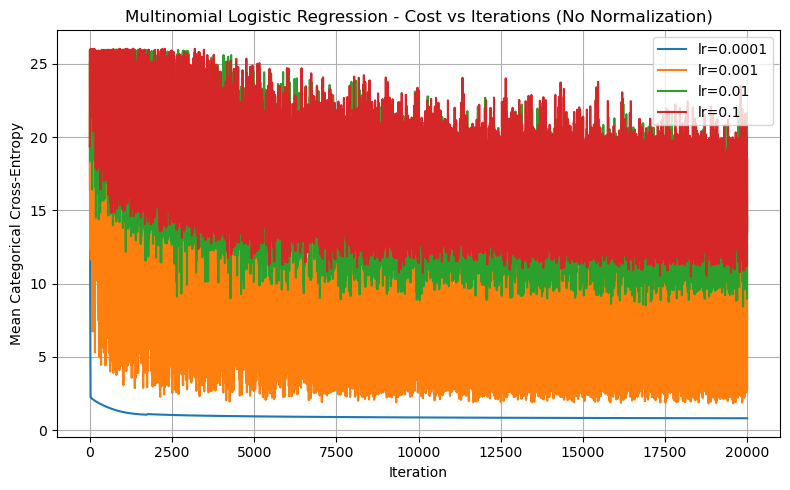

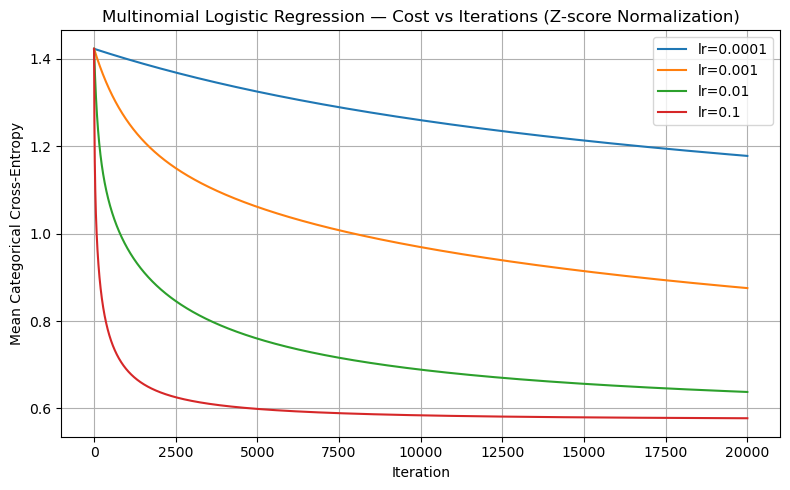

In [6]:
def MLR_select_lr(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot, lr_list=[0.0001, 0.001, 0.01, 0.1], num_iters=20000):
    """
    Args:
        FS_X_train (np.ndarray): Feature matrix for training.
        FS_X_val (np.ndarray): Feature matrix for validation.
        FS_X_test (np.ndarray): Feature matrix for testing.
        Ytr_onehot (np.ndarray): One-hot encoded labels for training.
        Yval_onehot (np.ndarray): One-hot encoded labels for validation.
        Yts_onehot (np.ndarray): One-hot encoded labels for testing.
        lr_list (list): List of learning rates to test.
        num_iters (int): Number of iterations for training.

    Returns:
        cost_dict (dict): Dictionary of cost values for each learning rate without input normalization.
                          example: cost_dict = {0.0001: [0.1, 0.05, ...], 0.001: [0.09, 0.045, ...], ...}
        acc_train_list_Log (list): Training accuracies for each learning rate without input normalization.
        acc_val_list_Log (list): Validation accuracies for each learning rate without input normalization.
        best_lr (float): Best learning rate based on validation accuracy without input normalization.
        test_acc_Log (float): Test accuracy for the best learning rate without input normalization.
        cost_dict_norm (dict): Dictionary of cost values for each learning rate with input normalization.
        acc_train_list_Log_norm (list): Training accuracies for each learning rate with input normalization.
        acc_val_list_Log_norm (list): Validation accuracies for each learning rate with input normalization.
        best_lr_norm (float): Best learning rate based on validation accuracy with input normalization.
        test_acc_Log_norm (float): Test accuracy for the best learning rate with input normalization.

    """
    
    # your code goes here
    SEED = 920
    def add_bias(X):
        return np.hstack([X, np.ones((X.shape[0], 1))])
    
    def softmax_stable(Z):
        Zmax = Z.max(axis=1, keepdims=True)
        EZ = np.exp(Z - Zmax)
        return EZ / EZ.sum(axis=1, keepdims=True)
    
    def multi_logistic_cost_gradient(X, w, Y, eps=1e-15):
        Z = X @ w
        P = softmax_stable(Z)
        P = np.clip(P, eps, 1 - eps)
        N = X.shape[0]
        cost = -np.sum(Y * np.log(P)) / N
        grad = (X.T @ (P - Y)) / N
        return P, cost, grad

    def multinominal_logistic_regression(P, W_init, Y, lr, num_iterates):
        W = W_init.copy()
        cost_vec = np.zeros(num_iterates + 1, dtype=float)
        P0, c0, g0 = multi_logistic_cost_gradient(P, W, Y)
        cost_vec[0] = c0
        grad = g0

        for i in range(1, num_iterates + 1):
            W -= lr * grad
            _, c, grad = multi_logistic_cost_gradient(P, W, Y)
            cost_vec[i] = c

        P_final, _, _ = multi_logistic_cost_gradient(P, W, Y)
        return W, cost_vec, P_final
    
    X_train = add_bias(FS_X_train)
    X_val = add_bias(FS_X_val)
    X_test = add_bias(FS_X_test)

    cost_dict = {}
    acc_train_list_Log = []
    acc_val_list_Log = []
    best_lr = None
    best_val_acc = -np.inf
    best_W = None

    for lr in lr_list:
        np.random.seed(SEED)
        W0 = np.random.normal(0, 0.1, size=(X_train.shape[1], Ytr_onehot.shape[1]))

        W_opt, cost_vec, P_tr_final = multinominal_logistic_regression(X_train, W0, Ytr_onehot, lr, num_iters)
        cost_dict[lr] = cost_vec

        ytr_idx = Ytr_onehot.argmax(axis=1)
        yval_idx = Yval_onehot.argmax(axis=1)
        yhat_tr = (X_train @ W_opt).argmax(axis=1)
        yhat_val = (X_val @ W_opt).argmax(axis=1)
        acc_tr = accuracy_score(ytr_idx, yhat_tr)
        acc_val = accuracy_score(yval_idx, yhat_val)
        acc_train_list_Log.append(acc_tr)
        acc_val_list_Log.append(acc_val)

        if acc_val > best_val_acc:
            best_val_acc = acc_val
            best_lr = lr
            best_W = W_opt

    yts_idx = Yts_onehot.argmax(axis=1)
    yhat_ts = (X_test @ best_W).argmax(axis=1)
    test_acc_Log = accuracy_score(yts_idx, yhat_ts)


    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr_n = scaler.fit_transform(FS_X_train)
    Xval_n = scaler.fit_transform(FS_X_val)
    Xts_n = scaler.fit_transform(FS_X_test)

    X_train_n = add_bias(Xtr_n)
    X_val_n = add_bias(Xval_n)
    X_test_n = add_bias(Xts_n)

    cost_dict_norm = {}
    acc_train_list_Log_norm = []
    acc_val_list_Log_norm = []
    best_lr_norm = None
    best_val_acc_n = -np.inf
    best_W_n = None

    for lr in lr_list:
        np.random.seed(SEED)
        W0 = np.random.normal(0, 0.1, size=(X_train_n.shape[1], Ytr_onehot.shape[1]))
        W_opt, cost_vec, _ = multinominal_logistic_regression(X_train_n, W0, Ytr_onehot, lr, num_iters)
        cost_dict_norm[lr] = cost_vec
        ytr_idx = Ytr_onehot.argmax(axis=1)
        yval_idx = Yval_onehot.argmax(axis=1)
        yhat_tr_n = (X_train_n @ W_opt).argmax(axis=1)
        yhat_val_n = (X_val_n @ W_opt).argmax(axis=1)
        acc_tr_n = accuracy_score(ytr_idx, yhat_tr_n)
        acc_val_n = accuracy_score(yval_idx, yhat_val_n)
        acc_train_list_Log_norm.append(acc_tr_n)
        acc_val_list_Log_norm.append(acc_val_n)

        if acc_val_n > best_val_acc_n:
            best_val_acc_n = acc_val_n
            best_lr_norm = lr
            best_W_n = W_opt

    yhat_ts_n = (X_test_n @ best_W_n).argmax(axis=1)
    test_acc_Log_norm = accuracy_score(yts_idx, yhat_ts_n)
    # return in this order      
    return cost_dict,acc_train_list_Log, acc_val_list_Log, best_lr,test_acc_Log, cost_dict_norm, acc_train_list_Log_norm, acc_val_list_Log_norm, best_lr_norm, test_acc_Log_norm

def cost_vs_iter_curve (cost_dict, cost_dict_norm):
     """
    Args:
        cost_dict (dict): Dictionary of cost values for each learning rate without input normalization.
        cost_dict_norm (dict): Dictionary of cost values for each learning rate with input normalization.

    """

    # your code goes here
     plt.figure(figsize=(8,5))
     for lr in sorted(cost_dict.keys()):
         costs = np.asarray(cost_dict[lr])
         plt.plot(np.arange(costs.shape[0]), costs, label = f'lr={lr}')
     plt.xlabel('Iteration')
     plt.ylabel('Mean Categorical Cross-Entropy')
     plt.title('Multinomial Logistic Regression - Cost vs Iterations (No Normalization)')
     plt.legend()
     plt.grid(True)
     plt.tight_layout()
     plt.show()

     plt.figure(figsize=(8,5))
     for lr in sorted(cost_dict_norm.keys()):
         costs = np.asarray(cost_dict_norm[lr])
         plt.plot(np.arange(costs.shape[0]), costs, label=f'lr={lr}')
     plt.xlabel('Iteration')
     plt.ylabel('Mean Categorical Cross-Entropy')
     plt.title('Multinomial Logistic Regression — Cost vs Iterations (Z-score Normalization)')
     plt.legend()
     plt.grid(True)
     plt.tight_layout()
     plt.show()


cost_dict,acc_train_list_Log, acc_val_list_Log, best_lr,test_acc_Log, cost_dict_norm, acc_train_list_Log_norm, acc_val_list_Log_norm, best_lr_norm, test_acc_Log_norm = MLR_select_lr(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot)

print(f"Without Normalization")
print(f"Training accuracies for different learning rates: {np.round(acc_train_list_Log,2)}")
print(f"Validation accuracies for different learning rates: {np.round(acc_val_list_Log,2)}")
print(f"Best learning rate: {best_lr}")
print(f"Test accuracy for best learning rate {best_lr}: {np.round(test_acc_Log,2)}")


print(f"With Z-score Standardization")
print(f"Training accuracies for different learning rates: {np.round(acc_train_list_Log_norm,2)}")
print(f"Validation accuracies for different learning rates: {np.round(acc_val_list_Log_norm,2)}")
print(f"Best learning rate: {best_lr_norm}")
print(f"Test accuracy for best learning rate {best_lr_norm}: {np.round(test_acc_Log_norm,2)}")

cost_vs_iter_curve (cost_dict, cost_dict_norm)

### Analysis of Effect of Normalization Based on Your Results

1. Stability & Convergence:

    i. Without Normalization (Graph 1): The training process appears very unstable for larger learning rates (lr=0.01 and especially lr=0.1). The cost function oscillates wildly and converges to very high values, or doesn't converge properly within the 20,000 iterations. Only the smallest learning rate (lr=0.0001) shows relatively stable convergence, but it's slow. The intermediate rate (lr=0.001) is also quite noisy. This instability suggests that the unscaled features have vastly different ranges, making gradient descent sensitive to the learning rate.

    ii. With Z-score Normalization (Graph 2): The training is much more stable across all tested learning rates. All curves show smooth convergence without the wild oscillations seen in the first graph. Even the largest learning rate (lr=0.1) converges smoothly to the lowest cost. Normalization makes the optimization landscape easier for gradient descent to navigate.

2. Convergence Speed & Final Cost:

    i. Without Normalization (Graph 1): Only the smallest learning rate (0.0001) seems to reach a reasonably low cost, but it does so very slowly. The other learning rates get stuck at much higher costs due to instability.

    ii. With Z-score Normalization (Graph 2): Convergence is significantly faster, especially with larger learning rates (0.01 and 0.1). These larger rates also achieve a lower final cost within the given iterations compared to the smaller ones. For example, lr=0.1 reaches a cost below 0.6 much faster than any other rate.

3. Impact on Learning Rate Selection:

    i. Without Normalization: You would likely be forced to choose a very small learning rate (like 0.0001) to ensure stability, leading to slow training.

    ii. With Z-score Normalization: You can safely choose a much larger learning rate (like 0.01 or 0.1) to achieve faster convergence and potentially a better final model (lower cost).